In [2]:
# Import libraries

import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Train-Test Split
from sklearn.model_selection import train_test_split

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

# Hyperparameter tuning
from sklearn.model_selection import GridSearchCV

In [3]:
df = pd.read_csv("C:/Users/geeth/OneDrive/Desktop/ott_movies_clean_unique.csv")

In [4]:
df

,content_id,title,type,genre,platform,country,language,release_year,duration_minutes,rating,votes,weighted_rating,engagement_score,popularity_score,trending_score,tags,combined_features,description,poster_url
0,C100146,Silent Code 146,Series,Drama,Netflix,UK,English,2024,819,9.5,198380,9.44,2707.89,1872.71,2198.94,"Drama,Netflix,Series,English",Drama Netflix Series Silent Code 146 is a dram...,"Silent Code 146 is a drama series on Netflix, ...",https://via.placeholder.com/150
1,C100452,Crimson Truth 452,Movie,Action,Netflix,Germany,German,2020,104,8.8,199426,8.76,345.67,1746.97,2014.24,"Action,Netflix,Movie,German",Action Netflix Movie Crimson Truth 452 is a ac...,Crimson Truth 452 is a action movie on Netflix...,https://via.placeholder.com/150
2,C101169,Cyber Night 1169,Series,Thriller,Prime Video,Germany,German,2022,1616,8.2,198549,8.17,5347.59,1622.15,1936.39,"Thriller,Prime Video,Series,German",Thriller Prime Video Series Cyber Night 1169 i...,Cyber Night 1169 is a thriller series on Prime...,https://via.placeholder.com/150
3,C100271,Silent Code 271,Movie,Sci-Fi,Netflix,India,Spanish,2022,117,8.7,194802,8.66,379.86,1686.99,1920.09,"Sci-Fi,Netflix,Movie,Spanish",Sci-Fi Netflix Movie Silent Code 271 is a sci-...,"Silent Code 271 is a sci-fi movie on Netflix, ...",https://via.placeholder.com/150
4,C100591,Silent Code 591,Movie,Drama,Hotstar,Germany,Hindi,2016,99,8.5,196936,8.46,324.94,1666.08,1899.82,"Drama,Hotstar,Movie,Hindi",Drama Hotstar Movie Silent Code 591 is a drama...,"Silent Code 591 is a drama movie on Hotstar, f...",https://via.placeholder.com/150
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,C101061,Lost Signal 1061,Series,Sci-Fi,Netflix,Spain,Hindi,2016,958,7.9,830,7.13,13.25,5.92,6.94,"Sci-Fi,Netflix,Series,Hindi",Sci-Fi Netflix Series Lost Signal 1061 is a sc...,Lost Signal 1061 is a sci-fi series on Netflix...,https://via.placeholder.com/150
2496,C102365,Neon Streets 2365,Movie,Sci-Fi,Hotstar,USA,German,2021,81,6.7,838,6.96,1.13,5.83,5.69,"Sci-Fi,Hotstar,Movie,German",Sci-Fi Hotstar Movie Neon Streets 2365 is a sc...,Neon Streets 2365 is a sci-fi movie on Hotstar...,https://via.placeholder.com/150
2497,C102307,Silent Code 2307,Movie,Sci-Fi,Prime Video,Spain,German,2024,91,6.9,703,6.99,1.07,4.91,5.00,"Sci-Fi,Prime Video,Movie,German",Sci-Fi Prime Video Movie Silent Code 2307 is a...,Silent Code 2307 is a sci-fi movie on Prime Vi...,https://via.placeholder.com/150
2498,C101632,Silent Code 1632,Movie,Comedy,Prime Video,UK,Korean,2020,82,7.5,524,7.05,0.72,3.69,3.97,"Comedy,Prime Video,Movie,Korean",Comedy Prime Video Movie Silent Code 1632 is a...,Silent Code 1632 is a comedy movie on Prime Vi...,https://via.placeholder.com/150


In [5]:
df.head()

,content_id,title,type,genre,platform,country,language,release_year,duration_minutes,rating,votes,weighted_rating,engagement_score,popularity_score,trending_score,tags,combined_features,description,poster_url
0,C100146,Silent Code 146,Series,Drama,Netflix,UK,English,2024,819,9.5,198380,9.44,2707.89,1872.71,2198.94,"Drama,Netflix,Series,English",Drama Netflix Series Silent Code 146 is a dram...,"Silent Code 146 is a drama series on Netflix, ...",https://via.placeholder.com/150
1,C100452,Crimson Truth 452,Movie,Action,Netflix,Germany,German,2020,104,8.8,199426,8.76,345.67,1746.97,2014.24,"Action,Netflix,Movie,German",Action Netflix Movie Crimson Truth 452 is a ac...,Crimson Truth 452 is a action movie on Netflix...,https://via.placeholder.com/150
2,C101169,Cyber Night 1169,Series,Thriller,Prime Video,Germany,German,2022,1616,8.2,198549,8.17,5347.59,1622.15,1936.39,"Thriller,Prime Video,Series,German",Thriller Prime Video Series Cyber Night 1169 i...,Cyber Night 1169 is a thriller series on Prime...,https://via.placeholder.com/150
3,C100271,Silent Code 271,Movie,Sci-Fi,Netflix,India,Spanish,2022,117,8.7,194802,8.66,379.86,1686.99,1920.09,"Sci-Fi,Netflix,Movie,Spanish",Sci-Fi Netflix Movie Silent Code 271 is a sci-...,"Silent Code 271 is a sci-fi movie on Netflix, ...",https://via.placeholder.com/150
4,C100591,Silent Code 591,Movie,Drama,Hotstar,Germany,Hindi,2016,99,8.5,196936,8.46,324.94,1666.08,1899.82,"Drama,Hotstar,Movie,Hindi",Drama Hotstar Movie Silent Code 591 is a drama...,"Silent Code 591 is a drama movie on Hotstar, f...",https://via.placeholder.com/150


In [6]:
print("Shape of dataset:", df.shape)

Shape of dataset: (2500, 19)


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   content_id         2500 non-null   object 
 1   title              2500 non-null   object 
 2   type               2500 non-null   object 
 3   genre              2500 non-null   object 
 4   platform           2500 non-null   object 
 5   country            2500 non-null   object 
 6   language           2500 non-null   object 
 7   release_year       2500 non-null   int64  
 8   duration_minutes   2500 non-null   int64  
 9   rating             2500 non-null   float64
 10  votes              2500 non-null   int64  
 11  weighted_rating    2500 non-null   float64
 12  engagement_score   2500 non-null   float64
 13  popularity_score   2500 non-null   float64
 14  trending_score     2500 non-null   float64
 15  tags               2500 non-null   object 
 16  combined_features  2500 

In [8]:
df.describe()

,release_year,duration_minutes,rating,votes,weighted_rating,engagement_score,popularity_score,trending_score
count,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,2019.578800,634.919600,7.487160,100467.058400,7.443576,1071.840288,747.735336,747.113316
std,2.861864,617.055317,0.980232,57448.910838,0.902874,1340.836601,441.421568,451.923130
min,2015.000000,80.000000,5.000000,524.000000,5.050000,0.720000,3.690000,3.300000
25%,2017.000000,128.000000,6.800000,51093.000000,6.810000,176.762500,382.855000,377.722500
50%,2020.000000,302.000000,7.500000,100687.000000,7.470000,394.305000,734.675000,727.615000
75%,2022.000000,1116.000000,8.200000,150191.250000,8.070000,1563.737500,1096.752500,1076.977500
max,2024.000000,2000.000000,9.500000,199813.000000,9.440000,6336.530000,1872.710000,2198.940000


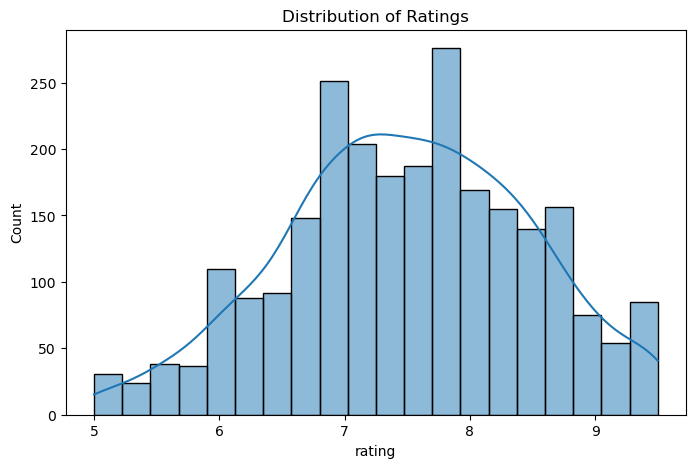

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df['rating'], bins=20, kde=True)

plt.title("Distribution of Ratings")
plt.show()

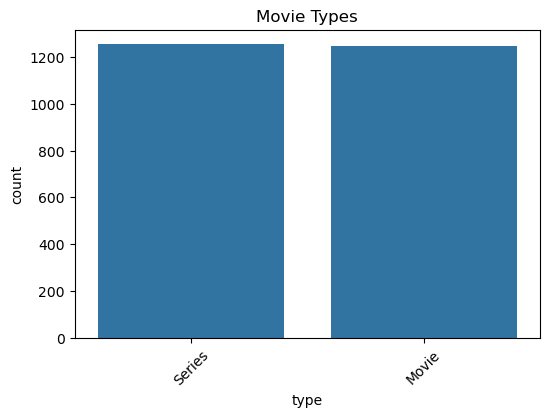

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(x='type', data=df)

plt.title("Movie Types")
plt.xticks(rotation=45)
plt.show()

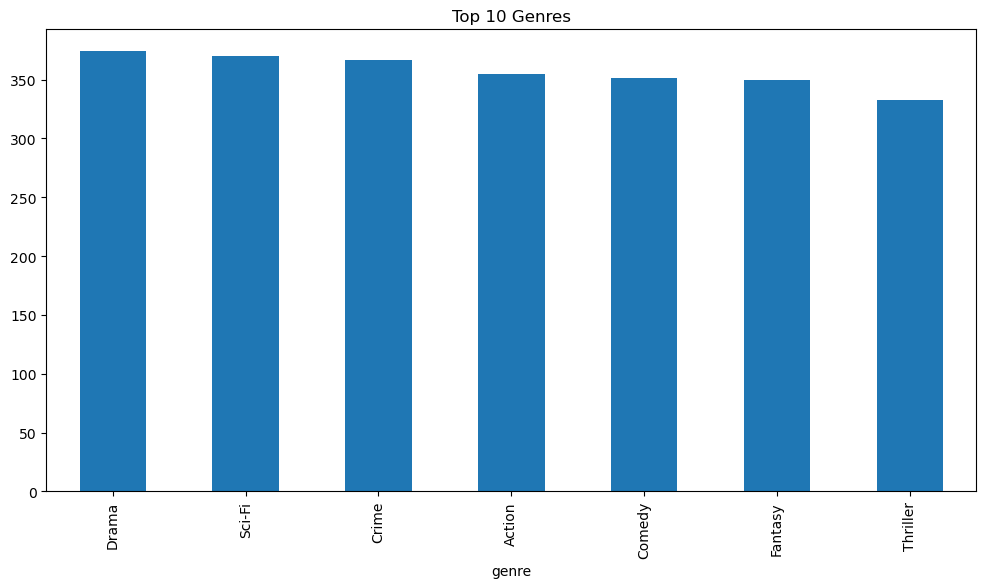

In [11]:
plt.figure(figsize=(12,6))

df['genre'].value_counts().head(10).plot(kind='bar')

plt.title("Top 10 Genres")
plt.show()

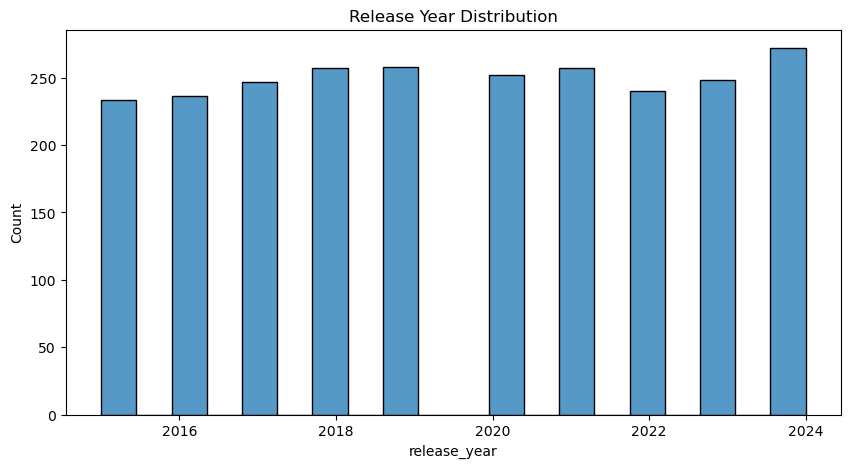

In [12]:
plt.figure(figsize=(10,5))

sns.histplot(df['release_year'], bins=20)

plt.title("Release Year Distribution")
plt.show()

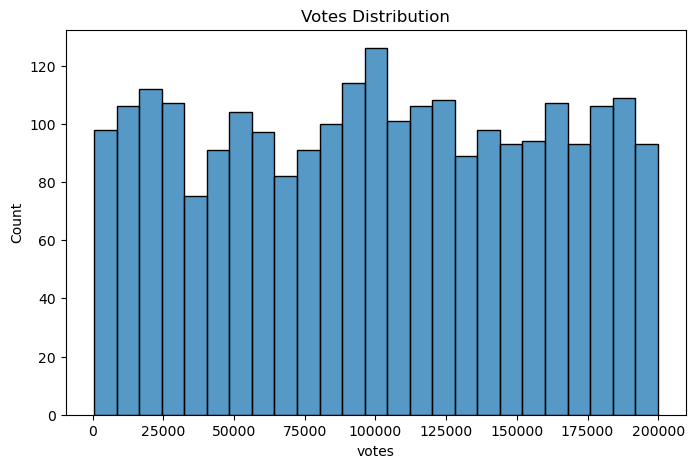

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(df['votes'], bins=25)

plt.title("Votes Distribution")
plt.show()

In [14]:
df_corr = df.copy()

label = LabelEncoder()

for col in df_corr.select_dtypes(include='object').columns:
    df_corr[col] = label.fit_transform(df_corr[col].astype(str))

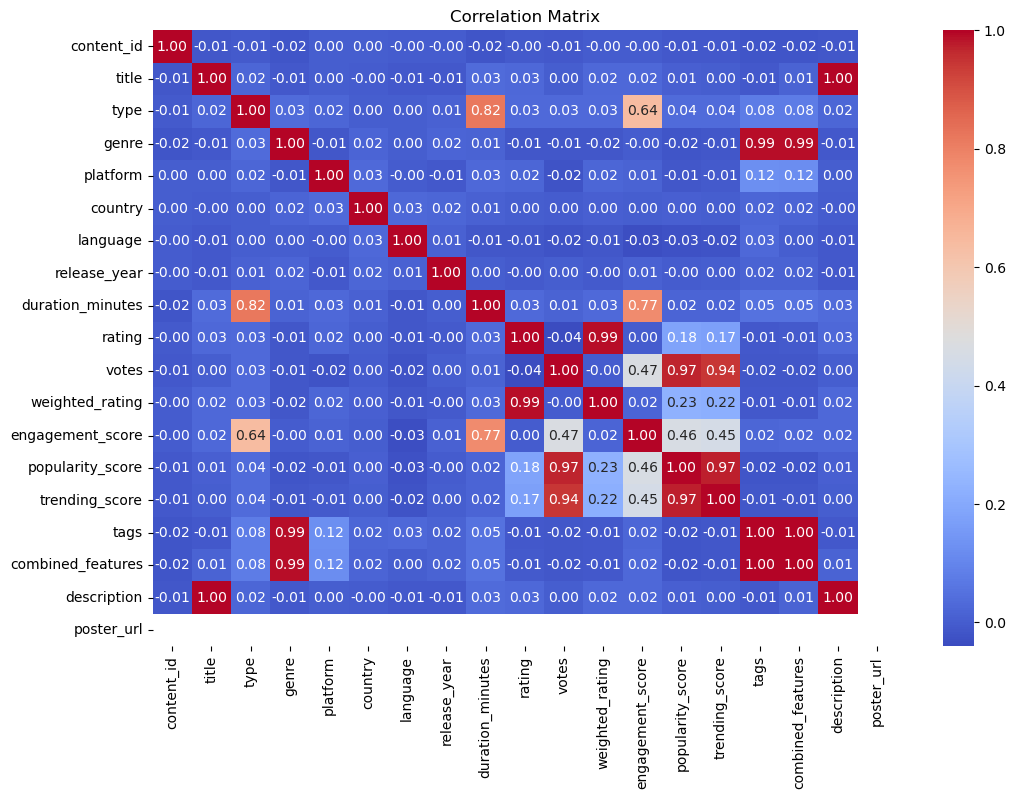

In [15]:
corr = df_corr.corr()

plt.figure(figsize=(12,8))

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title("Correlation Matrix")
plt.show()

In [16]:
# Check missing values
df.isnull().sum()

content_id           0
title                0
type                 0
genre                0
platform             0
country              0
language             0
release_year         0
duration_minutes     0
rating               0
votes                0
weighted_rating      0
engagement_score     0
popularity_score     0
trending_score       0
tags                 0
combined_features    0
description          0
poster_url           0
dtype: int64

In [20]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [21]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [22]:
df.dtypes

content_id            object
title                 object
type                  object
genre                 object
platform              object
country               object
language              object
release_year           int64
duration_minutes       int64
rating               float64
votes                  int64
weighted_rating      float64
engagement_score     float64
popularity_score     float64
trending_score       float64
tags                  object
combined_features     object
description           object
poster_url            object
dtype: object

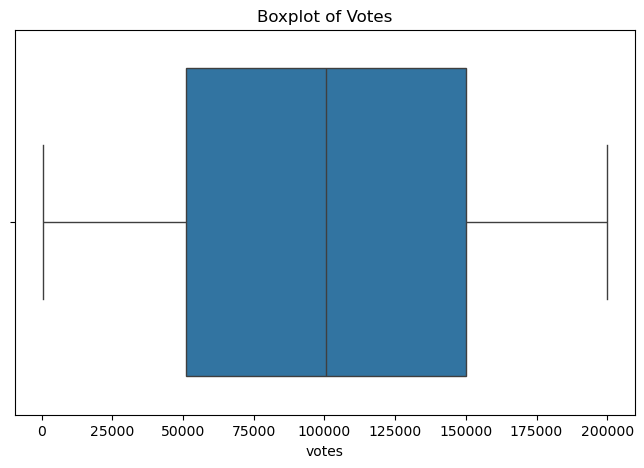

In [23]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['votes'])

plt.title("Boxplot of Votes")
plt.show()

In [24]:
Q1 = df['votes'].quantile(0.25)
Q3 = df['votes'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['votes'] >= lower) & (df['votes'] <= upper)]

print(df.shape)

(2500, 19)


In [25]:
df[['rating', 'votes', 'duration_minutes']].skew()

rating             -0.126249
votes              -0.018305
duration_minutes    0.810370
dtype: float64

In [26]:
df['Recommended'] = np.where(df['rating'] >= 7, 1, 0)

df[['rating', 'Recommended']].head()

,rating,Recommended
0,9.5,1
1,8.8,1
2,8.2,1
3,8.7,1
4,8.5,1


In [37]:
X = df.drop(['Recommended'], axis=1)

y = df['Recommended']

In [39]:
print(X.select_dtypes(include='object').columns)

Index(['content_id', 'title', 'type', 'genre', 'platform', 'country',
       'language', 'tags', 'combined_features', 'description', 'poster_url'],
      dtype='object')


In [41]:
for col in X.select_dtypes(include='object').columns:
    print(f"\nColumn: {col}")
    print(X[col].head())


Column: content_id
0    C100146
1    C100452
2    C101169
3    C100271
4    C100591
Name: content_id, dtype: object

Column: title
0      Silent Code 146
1    Crimson Truth 452
2     Cyber Night 1169
3      Silent Code 271
4      Silent Code 591
Name: title, dtype: object

Column: type
0    Series
1     Movie
2    Series
3     Movie
4     Movie
Name: type, dtype: object

Column: genre
0       Drama
1      Action
2    Thriller
3      Sci-Fi
4       Drama
Name: genre, dtype: object

Column: platform
0        Netflix
1        Netflix
2    Prime Video
3        Netflix
4        Hotstar
Name: platform, dtype: object

Column: country
0         UK
1    Germany
2    Germany
3      India
4    Germany
Name: country, dtype: object

Column: language
0    English
1     German
2     German
3    Spanish
4      Hindi
Name: language, dtype: object

Column: tags
0          Drama,Netflix,Series,English
1           Action,Netflix,Movie,German
2    Thriller,Prime Video,Series,German
3          Sci-Fi,Netfl

In [44]:
X = X.drop('content_id', axis=1)

In [45]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in X.select_dtypes(include='object').columns:
    X[col] = le.fit_transform(X[col].astype(str))

In [46]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [47]:
print(df.columns.tolist())

['content_id', 'title', 'type', 'genre', 'platform', 'country', 'language', 'release_year', 'duration_minutes', 'rating', 'votes', 'weighted_rating', 'engagement_score', 'popularity_score', 'trending_score', 'tags', 'combined_features', 'description', 'poster_url', 'Recommended']


In [48]:
from sklearn.preprocessing import LabelEncoder

label = LabelEncoder()

categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col] = label.fit_transform(df[col].astype(str))

In [49]:
X = df.drop(['Recommended'], axis=1)

y = df['Recommended']

In [50]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X, y)

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(by='Importance', ascending=False)

print(importance)

              Feature  Importance
9              rating    0.487862
11    weighted_rating    0.454378
13   popularity_score    0.020180
10              votes    0.013909
14     trending_score    0.011190
0          content_id    0.002189
12   engagement_score    0.002035
16  combined_features    0.001746
1               title    0.001602
17        description    0.001122
15               tags    0.000889
8    duration_minutes    0.000810
7        release_year    0.000526
6            language    0.000509
3               genre    0.000359
5             country    0.000294
4            platform    0.000267
2                type    0.000133
18         poster_url    0.000000


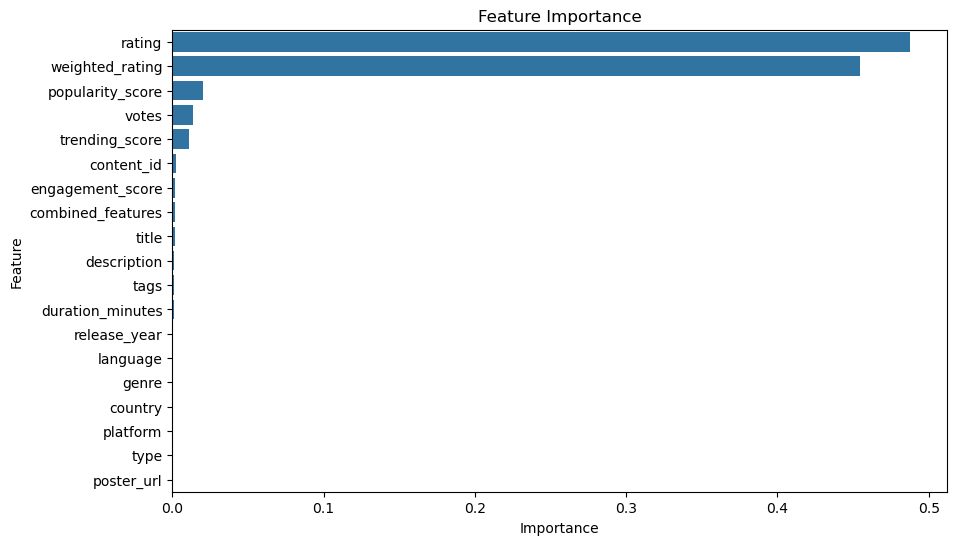

In [51]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title("Feature Importance")
plt.show()

In [52]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data :", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data : (2000, 19)
Testing Data : (500, 19)


In [53]:
X_train70, X_test70, y_train70, y_test70 = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("70:30 Train Shape:", X_train70.shape)
print("70:30 Test Shape:", X_test70.shape)

70:30 Train Shape: (1750, 19)
70:30 Test Shape: (750, 19)


In [54]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Accuracy:", lr.score(X_test, y_test))

Accuracy: 0.998


C:\Users\geeth\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [55]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       148
           1       1.00      1.00      1.00       352

    accuracy                           1.00       500
   macro avg       1.00      1.00      1.00       500
weighted avg       1.00      1.00      1.00       500



In [56]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Accuracy:", dt.score(X_test, y_test))

print(classification_report(y_test, y_pred_dt))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       148
           1       1.00      1.00      1.00       352

    accuracy                           1.00       500
   macro avg       1.00      1.00      1.00       500
weighted avg       1.00      1.00      1.00       500



In [57]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

print("Accuracy:", knn.score(X_test, y_test))

print(classification_report(y_test, y_pred_knn))

Accuracy: 0.644
              precision    recall  f1-score   support

           0       0.27      0.12      0.17       148
           1       0.70      0.86      0.77       352

    accuracy                           0.64       500
   macro avg       0.49      0.49      0.47       500
weighted avg       0.57      0.64      0.59       500



In [58]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Accuracy:", rf.score(X_test, y_test))

print(classification_report(y_test, y_pred_rf))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       148
           1       1.00      1.00      1.00       352

    accuracy                           1.00       500
   macro avg       1.00      1.00      1.00       500
weighted avg       1.00      1.00      1.00       500



In [64]:
lr = LogisticRegression(
    solver='liblinear',
    max_iter=2000,
    random_state=42
)

lr.fit(X_train, y_train)

LogisticRegression(max_iter=2000, random_state=42, solver='liblinear')

In [65]:
lr = LogisticRegression(
    max_iter=5000,
    random_state=42
)

lr.fit(X_train, y_train)

LogisticRegression(max_iter=5000, random_state=42)

In [60]:
dt_params = {
    'max_depth': [3, 5, 10, 15],
    'criterion': ['gini', 'entropy']
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_params,
    cv=5
)

grid_dt.fit(X_train, y_train)

print(grid_dt.best_params_)
print(grid_dt.best_score_)

{'criterion': 'gini', 'max_depth': 3}
0.9995


In [61]:
knn_params = {
    'n_neighbors': [3, 5, 7, 9]
}

grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    knn_params,
    cv=5
)

grid_knn.fit(X_train, y_train)

print(grid_knn.best_params_)
print(grid_knn.best_score_)

{'n_neighbors': 9}
0.6715000000000001


In [63]:
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 20]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    cv=5
)

grid_rf.fit(X_train, y_train)

print(grid_rf.best_params_)
print(grid_rf.best_score_)

{'max_depth': 5, 'n_estimators': 100}
1.0
